In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
from IPython.display import display


class Health:
    def __init__(self, df=None, filename=None):
        if filename:
            self.df = pd.read_csv(filename)
        elif df is not None:
            self.df = df
        else:
            raise ValueError("Please provide either a DataFrame or filename")

        
        if "Sleep Duration (hours)" in self.df.columns:
            self.df["Sleep Duration (hours)"] = pd.to_numeric(
                self.df["Sleep Duration (hours)"], errors="coerce"
            )

    
    def head(self, n=5):
        display(self.df.head(n))

    def tail(self, n=5):
        display(self.df.tail(n))

    def shape(self):
        return self.df.shape

    def info(self):
        return self.df.info()

    def columns(self):
        return self.df.columns.tolist()

    def data_types(self):
        return self.df.dtypes

    def describe(self):
        return self.df.describe(include="all")

    def null_summary(self):
        return pd.DataFrame({
            "Missing Values": self.df.isnull().sum(),
            "Missing %": round(self.df.isnull().mean()*100, 2)
        })

    
    def fillna_with_mean(self, col):
        if col in self.df.columns:
            self.df[col].fillna(self.df[col].mean(), inplace=True)

    def fillna_with_mode(self, col):
        if col in self.df.columns:
            self.df[col].fillna(self.df[col].mode()[0], inplace=True)

    def drop_nulls(self):
        self.df.dropna(inplace=True)

    def drop_duplicates(self):
        self.df.drop_duplicates(inplace=True)

    
    def detect_outliers(self, column):
        col = pd.to_numeric(self.df[column], errors='coerce').dropna()
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = self.df[(self.df[column] < lower) | (self.df[column] > upper)]
        return outliers[column].tolist()

    
    def plot_distribution(self, column):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df[column].dropna(), kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()

    def plot_count(self, column):
        plt.figure(figsize=(6, 4))
        sns.countplot(x=self.df[column])
        plt.title(f"Count Plot of {column}")
        plt.show()

    def plot_box(self, column):
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=self.df[column])
        plt.title(f"Boxplot of {column}")
        plt.show()

    def plot_scatter(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=self.df[x], y=self.df[y])
        plt.title(f"Scatter Plot: {x} vs {y}")
        plt.show()

    def correlation_heatmap(self):
        plt.figure(figsize=(8, 6))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()

    
    def chi_square(self, col1, col2):
        table = pd.crosstab(self.df[col1], self.df[col2])
        _, p, _, _ = chi2_contingency(table)
        return p

    def anova_test(self, target):
        cat_cols = self.df.select_dtypes(include="object").columns
        results = []
        for col in cat_cols:
            groups = [group[target].dropna().values for _, group in self.df.groupby(col)]
            if len(groups) > 1:
                stat, p = f_oneway(*groups)
                results.append({"Feature": col, "p-value": p})
        return pd.DataFrame(results)

    def save_to_csv(self, filename):
        self.df.to_csv(filename, index=False)


In [42]:
Sw_df = Health(filename='unclean_smartwatch_health_data.csv')

In [6]:
Sw_df.head()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1
1,NaN,NaN,98.532195,727.601610,6.538239,Highly_Active,5
2,1860.0,247.803052,97.052954,2826.521994,NaN,Highly Active,5
3,2294.0,40.000000,96.894213,13797.338044,7.367790,Actve,3
4,2130.0,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


In [7]:
Sw_df.tail() 

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
9995,1524.0,78.819386,98.931927,2948.491953,7.402749,Active,7
9996,4879.0,48.632659,95.773035,4725.623070,6.382166,Sedentary,2
9997,2624.0,73.834442,97.945874,2571.492060,6.916549,Sedentary,4
9998,4907.0,NaN,98.401058,3364.788855,5.691234,Active,8
9999,4113.0,70.063864,98.475606,544.696104,5.691001,Actve,5


In [8]:
Sw_df.shape() 

(10000, 7)

In [9]:
Sw_df.columns()

['User ID',
 'Heart Rate (BPM)',
 'Blood Oxygen Level (%)',
 'Step Count',
 'Sleep Duration (hours)',
 'Activity Level',
 'Stress Level']

In [10]:
Sw_df.data_types()

User ID                   float64
Heart Rate (BPM)          float64
Blood Oxygen Level (%)    float64
Step Count                float64
Sleep Duration (hours)    float64
Activity Level             object
Stress Level               object
dtype: object

In [11]:
Sw_df.describe()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
count,9799.000000,9600.000000,9700.000000,9900.000000,9603.000000,9800,9800
unique,NaN,NaN,NaN,NaN,NaN,6,11
top,NaN,NaN,NaN,NaN,NaN,Seddentary,2
freq,NaN,NaN,NaN,NaN,NaN,1676,1007
mean,3007.480253,76.035462,97.841581,6985.685885,6.505463,NaN,NaN
std,1150.581542,19.412483,1.732863,6885.809680,1.510029,NaN,NaN
min,1001.000000,40.000000,90.791208,0.910138,-0.194453,NaN,NaN
25%,1997.500000,64.890152,96.662683,2021.039657,5.493820,NaN,NaN
50%,2998.000000,75.220601,98.010642,4962.534599,6.503308,NaN,NaN
75%,4004.000000,85.198249,99.376179,9724.902880,7.529357,NaN,NaN


In [12]:
Sw_df.null_summary()

,Missing Values,Missing %
User ID,201,2.01
Heart Rate (BPM),400,4.00
Blood Oxygen Level (%),300,3.00
Step Count,100,1.00
Sleep Duration (hours),397,3.97
Activity Level,200,2.00
Stress Level,200,2.00


In [15]:
Sw_df.fillna_with_mode("Gender")     

In [16]:
Sw_df.drop_duplicates()

In [25]:
Sw_df.detect_outliers('Heart Rate (BPM)')

[247.8030522923432,
 118.29493321826284,
 200.49164217071984,
 219.1991782129313,
 232.9449069272243,
 264.46735633766275,
 226.2567250935164,
 265.5429095106564,
 117.71060779267508,
 207.1021876945045,
 130.3120020224745,
 207.43024338048195,
 117.15926886369355,
 215.19468105471688,
 204.0678112444548,
 209.77392353062743,
 228.4980779780263,
 256.377377355097,
 283.58578538080286,
 121.7452204952703,
 116.86122514348094,
 292.9232995560192,
 282.8631240383314,
 127.58807105317372,
 243.8769779618632,
 284.05525490682896,
 118.36817774758477,
 271.4957856042119,
 231.25544172033543,
 125.73364314352746,
 276.12398317377074,
 296.5939695131042,
 123.25475380185284,
 204.0576099318878,
 249.617291391865,
 269.1459746695917,
 250.62067876216804,
 246.0941444842628,
 115.73846179568152,
 118.5325595220546,
 264.64281151638994,
 231.0362871673195,
 234.8409357359941,
 122.10106676240682,
 274.2969041634161,
 257.82968587553705,
 263.37578972291664,
 118.94516529390434,
 116.8808981217648

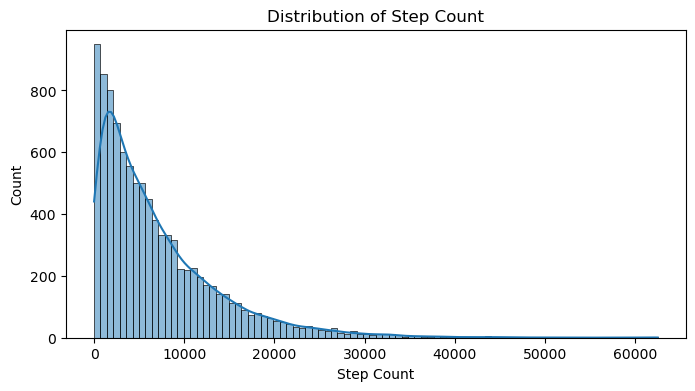

In [30]:
Sw_df.plot_distribution("Step Count")

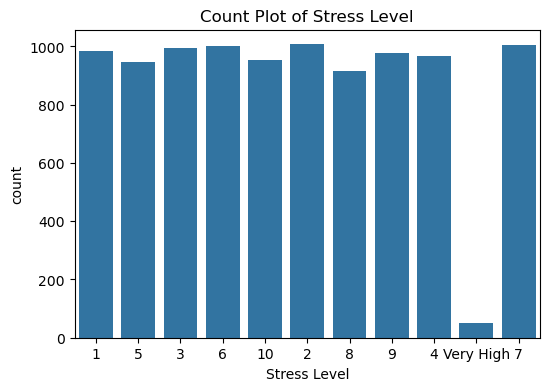

In [31]:
Sw_df.plot_count("Stress Level")

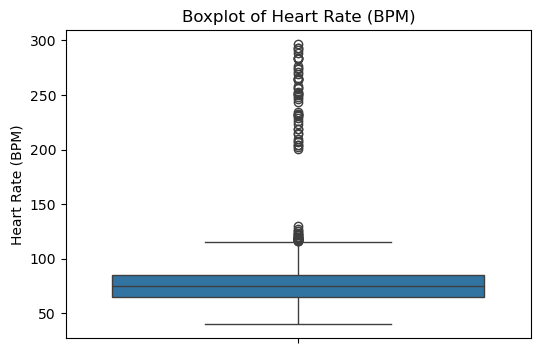

In [32]:
Sw_df.plot_box("Heart Rate (BPM)")

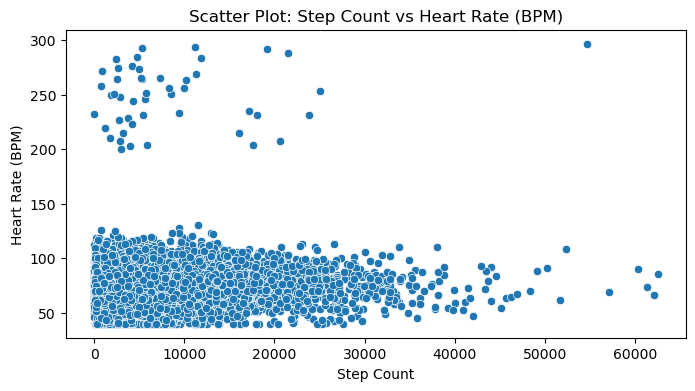

In [33]:
Sw_df.plot_scatter("Step Count", "Heart Rate (BPM)")

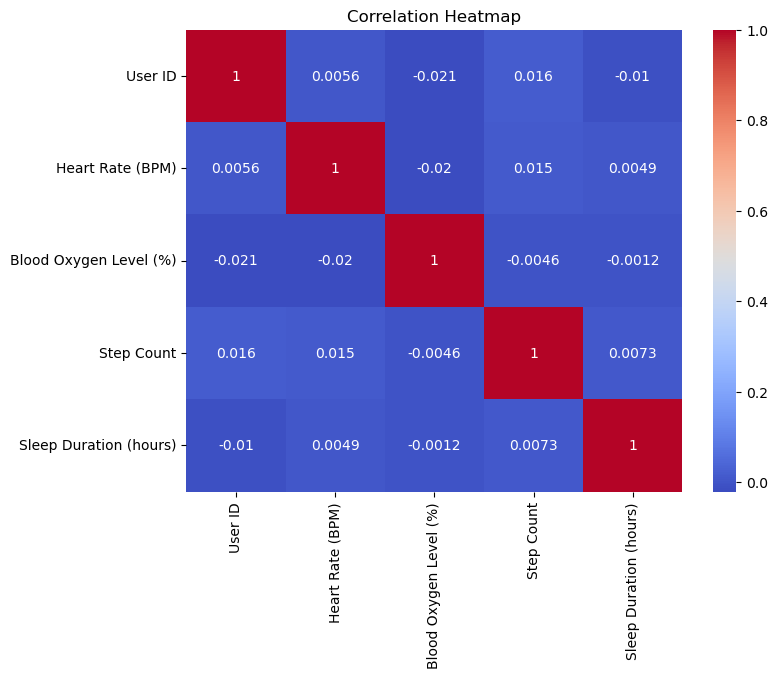

In [34]:
Sw_df.correlation_heatmap()

In [35]:
p_value = Sw_df.chi_square("Activity Level", "Stress Level")
print("Chi-Square p-value:", p_value)

Chi-Square p-value: 0.871754244164832


In [36]:
anova_results = Sw_df.anova_test("Heart Rate (BPM)")
print(anova_results)

          Feature   p-value
0  Activity Level  0.904516
1    Stress Level  0.932648
